## All-Activity Overview

Before narrowing to a shortlist, we ran the full analysis across all 20 activities in the
Nymeria dataset. This notebook exists as an overview of our analysis before we dive deep into the dataset and analyze the shortlisted activities.

**What this notebook covers:**

1. **Dataset coverage** — how many sessions and participants we have per activity,
so the reader can see the full scope of the data before any filtering decisions are made.

2. **Participant demographics** — age and gender breakdown across all participants
in the filtered dataset.

3. **Vertical gaze centroids** — mean pitch per activity ranked from most heads-down
to least, with 95% confidence intervals. This is the clearest signal in the data:
what you are doing strongly predicts where you look vertically.

4. **Population gaze density maps** — one heatmap per activity showing the average
gaze distribution across participants. Each map is a mean of per-session normalized
histograms, so every participant weighs equally regardless of session length.

5. **Pairwise Cohen's d** — effect sizes for pitch differences between every pair of
activities. Most pairs show large effects (|d| > 0.8), confirming that the vertical
gaze signal is not only statistically significant but practically meaningful.


In [1]:
from pathlib import Path

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import nymeria_gaze_tools as ngt

pio.renderers.default = "png"

DATA_ROOT    = Path("../data/processed")
SESSIONS_DIR = DATA_ROOT / "sessions_preprocessed"
FIGURES_DIR  = Path("figures/all20_overview")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = {
    "blue":   "#0072B2",
    "orange": "#E69F00",
    "yellow": "#F0E442",
}

print("Setup complete.")


Setup complete.


In [2]:
catalog = pd.read_csv(DATA_ROOT / "catalog_filtered.csv")

print(f"Sessions: {len(catalog)}  |  Participants: {catalog['fake_name'].nunique()}")
print(f"Activities: {catalog['script'].nunique()}")
print(f"\nSessions per activity:")
print(catalog.groupby("script").size().sort_values(ascending=False).to_string())


Sessions: 980  |  Participants: 228
Activities: 20

Sessions per activity:
script
S7-Cooking                128
S16-Simon_says            110
S12-Game_night            107
S2-Where_is_X             103
S10-Housekeeping           77
S3-Welcome_to_my_place     61
S19-Fresh_air              60
S8-Having_a_meal           50
S20-Party                  46
S11-Laundary               28
S13-Charades               27
S5-Workout                 26
S15-Do_as_I_command        25
S6-Dance                   22
S1-Relax_at_home           22
S17-In_the_office          21
S4-Body_stretch            19
S9-Making_a_mess           19
S18-Hike                   18
S14-By_my_desk             11


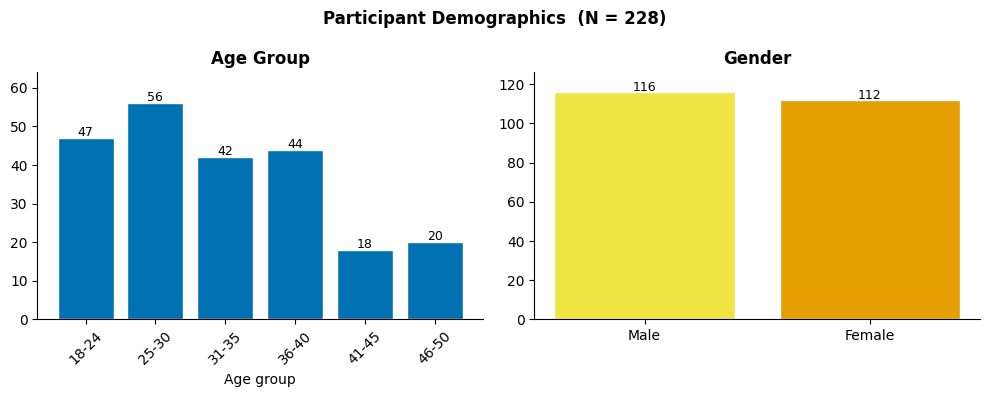

In [3]:
participants = catalog.drop_duplicates("fake_name").reset_index(drop=True)
n = len(participants)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Age group
age_order = ["18-24", "25-30", "31-35", "36-40", "41-45", "46-50"]
age = participants["participant_age_group"].value_counts().reindex(age_order)
axes[0].bar(age.index, age.values, color=PALETTE["blue"], edgecolor="white")
for i, v in enumerate(age.values):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontsize=9)
axes[0].set_xlabel("Age group")
axes[0].set_title("Age Group", fontweight="bold")
axes[0].set_ylim(0, age.max() + 8)
axes[0].tick_params(axis="x", labelrotation=45)
axes[0].spines[["top", "right"]].set_visible(False)

# Gender
gen = participants["participant_gender"].value_counts()
colors = [PALETTE["yellow"], PALETTE["orange"]]
axes[1].bar(gen.index, gen.values, color=colors, edgecolor="white")
for i, v in enumerate(gen.values):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontsize=9)
axes[1].set_title("Gender", fontweight="bold")
axes[1].set_ylim(0, gen.max() + 10)
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle(f"Participant Demographics  (N = {n})", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "demographics.png", dpi=150, bbox_inches="tight")
plt.show()


In [4]:
uids = catalog["sequence_uid"].tolist()
# The dataset has two gaze formats: "personalized" (separate left/right eye columns) and
# "general" (single yaw column). The preprocessing pipeline expects personalized format,
# so any general-gaze sessions will be missing from sessions_preprocessed/ and skipped here.
session_dfs = {}
skipped = []

print(f"Loading {len(uids)} sessions...")
for i, uid in enumerate(uids):
    if i % 50 == 0:
        print(f"  {i}/{len(uids)}")
    try:
        session_dfs[uid] = pd.read_parquet(SESSIONS_DIR / f"{uid}.parquet")
    except Exception as e:
        skipped.append((uid, str(e)))

print(f"\nDone. Loaded: {len(session_dfs)}  |  Skipped: {len(skipped)}")
for uid, err in skipped:
    print(f"  SKIP {uid} | {err}")


Loading 980 sessions...
  0/980
  50/980
  100/980
  150/980
  200/980
  250/980
  300/980
  350/980
  400/980
  450/980
  500/980
  550/980
  600/980
  650/980
  700/980
  750/980
  800/980
  850/980
  900/980
  950/980

Done. Loaded: 979  |  Skipped: 1
  SKIP 20230726_s1_thomas_nixon_act2_bsfnuw | [Errno 2] No such file or directory: '../data/processed/sessions_preprocessed/20230726_s1_thomas_nixon_act2_bsfnuw.parquet'


In [5]:
# One mean per session, then mean/SEM across sessions within each activity.
rows = []
for _, meta_row in catalog.iterrows():
    uid = meta_row["sequence_uid"]
    if uid not in session_dfs:
        continue
    df = session_dfs[uid]
    rows.append({
        "script":     meta_row["script"],
        "fake_name":  meta_row["fake_name"],
        "mean_yaw":   df["avg_yaw_deg"].mean(), # avg_yaw_deg = (left_yaw_deg + right_yaw_deg) / 2 per sample (binocular average, not time-averaged).
        "mean_pitch": df["pitch_deg"].mean(),   # pitch_deg is a single signal from the glasses — no left/right split exists for pitch.
    })

participant_means = pd.DataFrame(rows)

centroids = (participant_means
             .groupby("script")
             .agg(
                 centroid_yaw   = ("mean_yaw",   "mean"),
                 centroid_pitch = ("mean_pitch", "mean"),
                 yaw_se         = ("mean_yaw",   "sem"),
                 pitch_se       = ("mean_pitch", "sem"),
                 n              = ("fake_name",  "count"),
             )
             .reset_index())

print(centroids.sort_values("centroid_pitch").to_string(index=False))



                script  centroid_yaw  centroid_pitch   yaw_se  pitch_se   n
            S7-Cooking     -0.167712      -23.760633 0.180480  0.481583 128
          S11-Laundary     -1.467380      -23.249288 0.382068  1.171910  28
        S14-By_my_desk      0.893143      -21.637666 0.898033  1.726019  11
             S20-Party      0.111588      -21.431340 0.288213  0.579303  46
      S10-Housekeeping     -0.032909      -20.950721 0.244367  0.591706  77
      S8-Having_a_meal     -0.177426      -20.332366 0.347515  0.845097  50
        S12-Game_night     -0.451031      -20.032428 0.233740  0.538426 107
      S9-Making_a_mess     -1.146133      -18.892105 0.675251  1.309602  19
              S18-Hike      1.189995      -18.869536 0.378668  1.069979  18
              S6-Dance     -0.701599      -18.678793 0.662814  1.876906  21
        S16-Simon_says      0.214818      -18.144476 0.209177  0.586010 110
            S5-Workout     -0.493318      -17.637242 0.452426  1.570388  26
   S15-Do_as

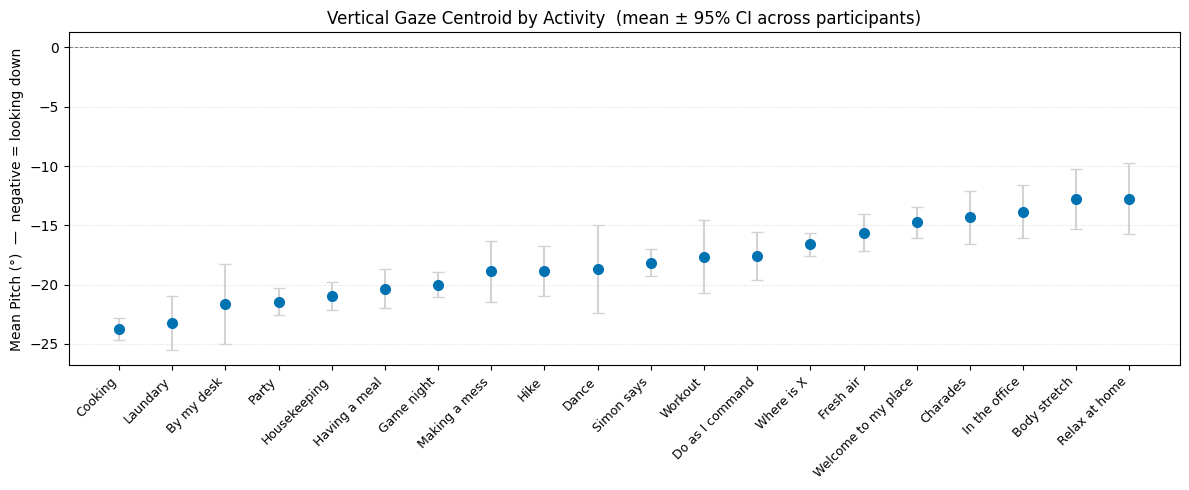

In [6]:
# Rank all activities by mean vertical gaze — the steeper the drop, the more heads-down the activity
plot_centroids = centroids.sort_values("centroid_pitch").reset_index(drop=True)
tick_labels = plot_centroids["script"].str.split("-", n=1).str[1].str.replace("_", " ")

fig, ax = plt.subplots(figsize=(12, 5))

ax.errorbar(
    x=range(len(plot_centroids)),
    y=plot_centroids["centroid_pitch"],
    yerr=plot_centroids["pitch_se"] * 1.96,
    fmt="o", color=PALETTE["blue"], ecolor="lightgray",
    elinewidth=1.5, capsize=4, markersize=7
)

ax.set_xticks(range(len(plot_centroids)))
ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=9)
ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
ax.set_ylabel("Mean Pitch (°)  —  negative = looking down")
ax.set_title("Vertical Gaze Centroid by Activity  (mean ± 95% CI across participants)")
ax.grid(axis="y", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "all20_pitch_centroids.png", dpi=150, bbox_inches="tight")
plt.show()


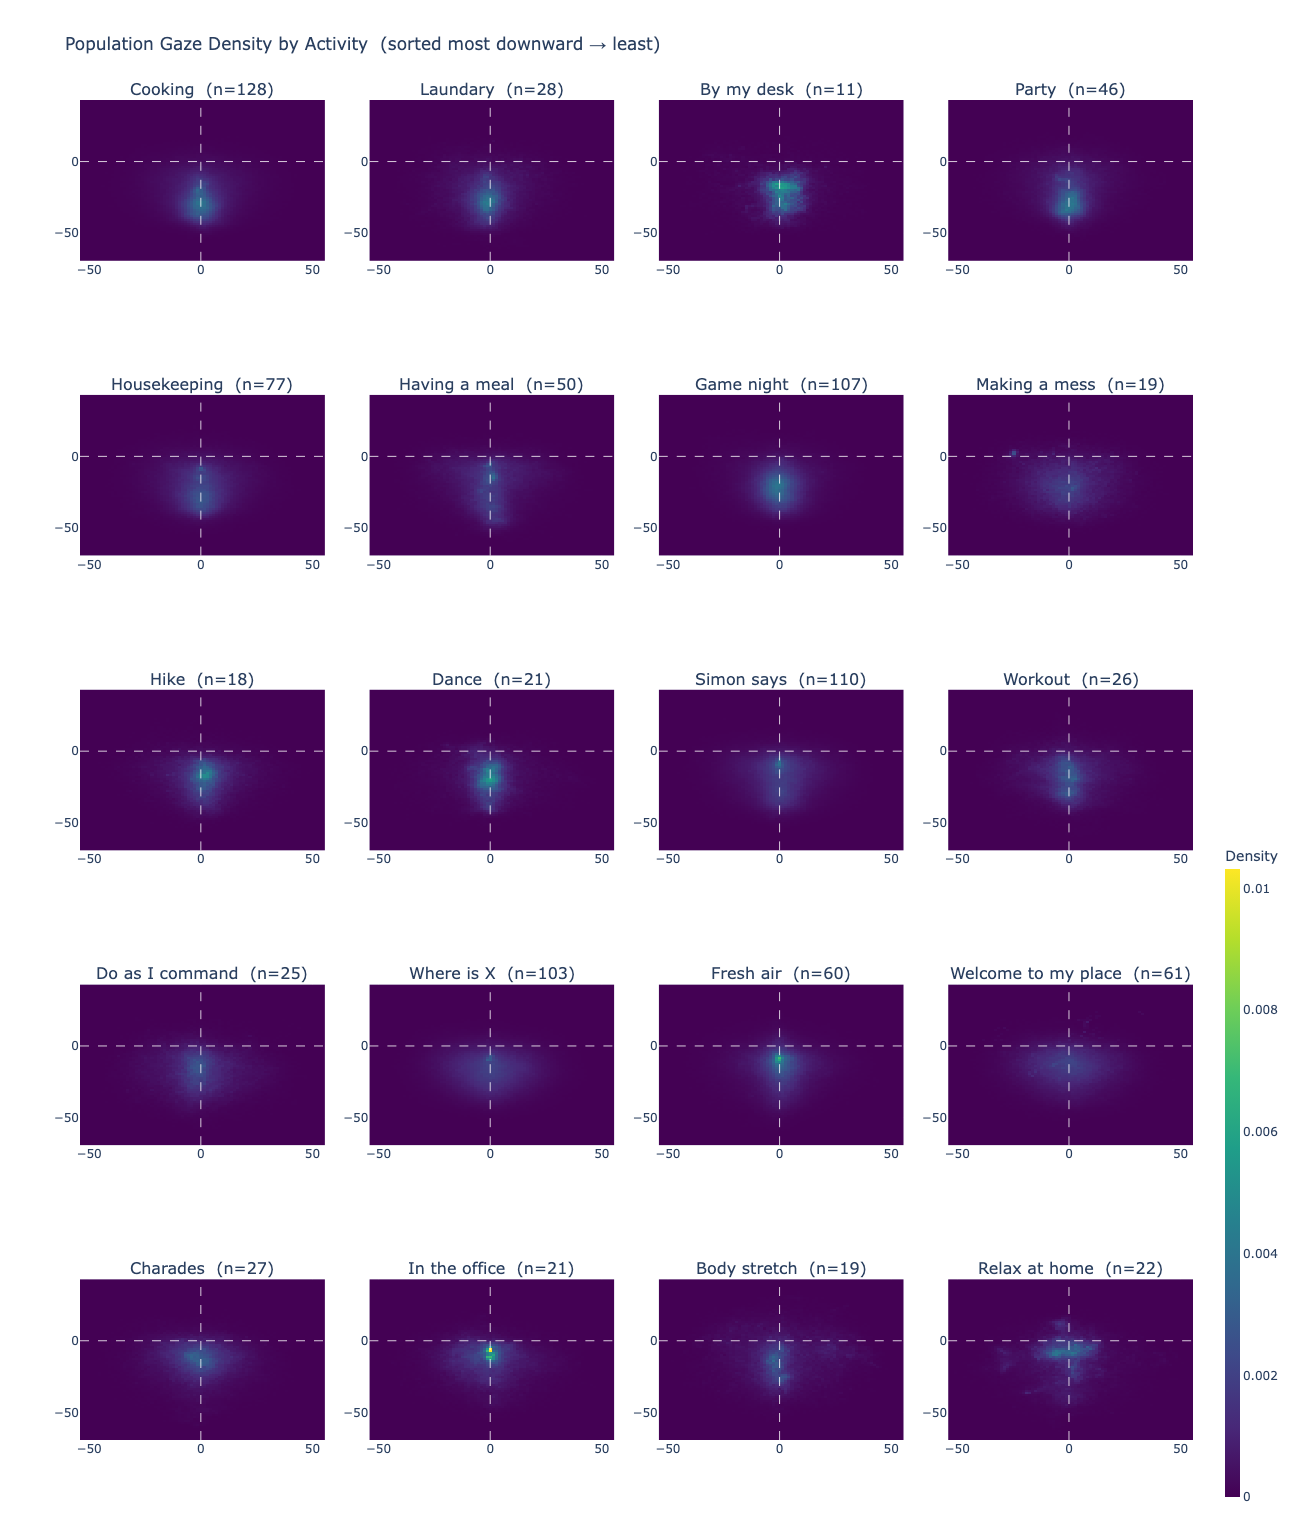

<Figure size 640x480 with 0 Axes>

In [7]:
# Per-activity population gaze density: average of per-session normalized 2D histograms on shared bins, sorted by pitch

BINS   = 80
N_COLS = 4

activity_order = centroids.sort_values("centroid_pitch")["script"].tolist()

all_dfs  = [session_dfs[uid] for uid in catalog["sequence_uid"] if uid in session_dfs]
x_all    = pd.concat([df["avg_yaw_deg"].dropna() for df in all_dfs])
y_all    = pd.concat([df["pitch_deg"].dropna()   for df in all_dfs])
x_edges  = np.linspace(x_all.min(), x_all.max(), BINS + 1)
y_edges  = np.linspace(y_all.min(), y_all.max(), BINS + 1)
x_ctr    = (x_edges[:-1] + x_edges[1:]) / 2
y_ctr    = (y_edges[:-1] + y_edges[1:]) / 2

groups = {}
for _, row in catalog.iterrows():
    uid = row["sequence_uid"]
    if uid not in session_dfs:
        continue
    script = row["script"]
    if script not in groups:
        groups[script] = []
    groups[script].append(session_dfs[uid])

z_maps = {}
for act, dfs in groups.items():
    maps = []
    for df in dfs:
        h, _, _ = np.histogram2d(df["avg_yaw_deg"].dropna(), df["pitch_deg"].dropna(),
                                 bins=[x_edges, y_edges])
        if h.sum() > 0:
            maps.append(h / h.sum())
    z_maps[act] = np.mean(maps, axis=0).T if maps else np.zeros((BINS, BINS))

zmin = min(z.min() for z in z_maps.values())
zmax = max(z.max() for z in z_maps.values())

n      = len(activity_order)
n_rows = math.ceil(n / N_COLS)
PANEL_SIZE = 280

subplot_titles = [
    f"{act.split('-', 1)[1].replace('_', ' ')}  (n={len(groups.get(act, []))})"
    for act in activity_order
]

fig = make_subplots(
    rows=n_rows, cols=N_COLS,
    subplot_titles=subplot_titles,
    horizontal_spacing=0.04,
    vertical_spacing=0.10,
)

for idx, act in enumerate(activity_order):
    row = idx // N_COLS + 1
    col = idx % N_COLS + 1
    is_last = idx == len(activity_order) - 1
    fig.add_trace(
        go.Heatmap(
            x=x_ctr, y=y_ctr, z=z_maps[act],
            colorscale="viridis",
            zmin=zmin, zmax=zmax,
            showscale=is_last,
            colorbar=dict(title="Density", thickness=15, len=0.5, y=0.2) if is_last else None,
        ),
        row=row, col=col,
    )
    fig.add_hline(y=0, line=dict(color="white", width=0.8, dash="dash"), row=row, col=col)
    fig.add_vline(x=0, line=dict(color="white", width=0.8, dash="dash"), row=row, col=col)

fig.update_layout(
    title_text="Population Gaze Density by Activity  (sorted most downward → least)",
    width=PANEL_SIZE * N_COLS + 180,
    height=PANEL_SIZE * n_rows + 120,
    autosize=False,
)
fig.show()
plt.savefig(FIGURES_DIR / "all20_density_grid.png", dpi=150, bbox_inches="tight")


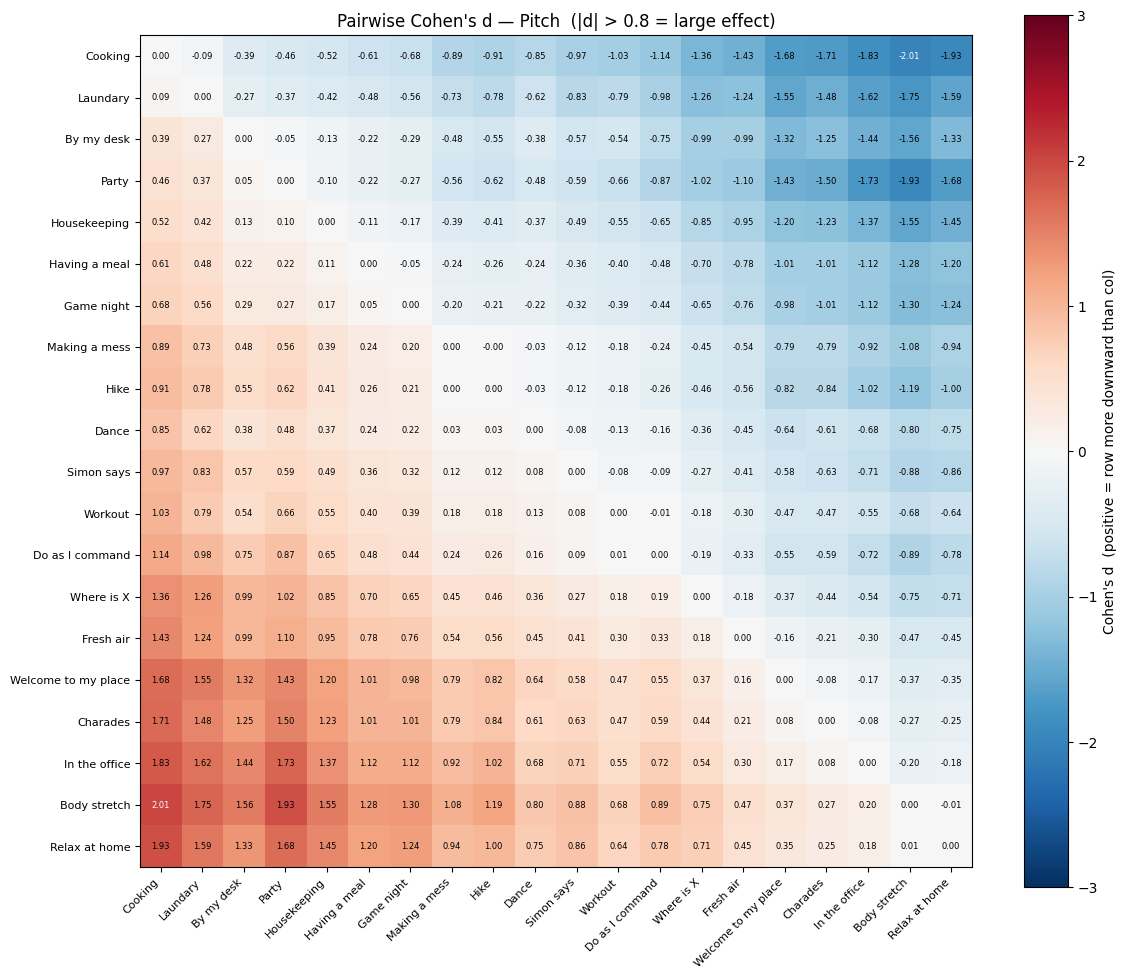

In [8]:
# Pairwise effect sizes between activities — confirms the pitch differences are not just statistically significant but practically meaningful
from itertools import combinations

def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_sd = np.sqrt(((na - 1) * a.std(ddof=1)**2 + (nb - 1) * b.std(ddof=1)**2) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_sd

pitch_order = (centroids.sort_values("centroid_pitch")["script"]
               .apply(lambda s: s.split("-", 1)[1].replace("_", " "))
               .tolist())
scripts     = centroids.sort_values("centroid_pitch")["script"].tolist()

d_matrix = pd.DataFrame(np.nan, index=pitch_order, columns=pitch_order)
for act in pitch_order:
    d_matrix.loc[act, act] = 0.0

for s1, s2 in combinations(scripts, 2):
    a  = participant_means[participant_means["script"] == s1]["mean_pitch"].values
    b  = participant_means[participant_means["script"] == s2]["mean_pitch"].values
    d  = cohens_d(a, b)
    l1 = s1.split("-", 1)[1].replace("_", " ")
    l2 = s2.split("-", 1)[1].replace("_", " ")
    d_matrix.loc[l1, l2] = d
    d_matrix.loc[l2, l1] = -d

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(d_matrix.values.astype(float), cmap="RdBu_r", vmin=-3, vmax=3)
plt.colorbar(im, ax=ax, label="Cohen's d  (positive = row more downward than col)")

ax.set_xticks(range(len(pitch_order)))
ax.set_yticks(range(len(pitch_order)))
ax.set_xticklabels(pitch_order, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(pitch_order, fontsize=8)

for i in range(len(pitch_order)):
    for j in range(len(pitch_order)):
        val = d_matrix.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=6, color="black" if abs(val) < 2 else "white")

ax.set_title("Pairwise Cohen's d — Pitch  (|d| > 0.8 = large effect)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "all20_cohens_d.png", dpi=150, bbox_inches="tight")
plt.show()
